In [1]:
from utils import get_gsm8k_df
from statistical_significance import compare_accuracies, compare_accuracies_v2, compare_accuracies_v3
import numpy as np
df = get_gsm8k_df("ReWOO")

gemma-3-27b-it.xlsx
qwen3_1.7b.xlsx
smollm2_360m.xlsx
qwen2-math_1.5b.xlsx
qwen3_0.6b.xlsx
qwen2.5_0.5b.xlsx
gemma3_1b.xlsx
deepseek-r1_1.5b.xlsx
llama3.2_1b.xlsx


# Misclassified

In [2]:
df_misc = get_gsm8k_df("ReWOO", include_misclassified=True)
df_misc = df_misc[df_misc["Error Type"] == "Misclassified"]
df_misc.groupby(["Model", "Error Class"]).agg({
    "question": "count",
}).reset_index().sort_values(by="question", ascending=False).head(50)

gemma-3-27b-it.xlsx
qwen3_1.7b.xlsx
smollm2_360m.xlsx
qwen2-math_1.5b.xlsx
qwen3_0.6b.xlsx
qwen2.5_0.5b.xlsx
gemma3_1b.xlsx
deepseek-r1_1.5b.xlsx
llama3.2_1b.xlsx


,Model,Error Class,question
0,deepseek-r1:1.5b,Misclassified,5
2,gemma3:1b,Misclassified,2
3,qwen2.5:0.5b,Misclassified,2
1,gemma-3-27b-it,Misclassified,1


In [3]:
overall_misc_rate = len(df_misc) / len(df)
print(f"Total misclassified examples: {len(df_misc)}")
print(f"Total examples: {len(df)}")
print(f"Overall misclassification rate: {overall_misc_rate:.2%}")

Total misclassified examples: 10
Total examples: 2700
Overall misclassification rate: 0.37%


# Accuracy

## Sorted

In [5]:
df_acc = df.groupby(["Model"]).agg({
    "is_correct": "mean",
}).reset_index().sort_values(by="is_correct", ascending=False)
df_acc["is_correct"] = df_acc["is_correct"] * 100
df_acc

,Model,is_correct
1,gemma-3-27b-it,89.000000
0,deepseek-r1:1.5b,77.333333
7,qwen3:1.7b,74.333333
6,qwen3:0.6b,55.333333
5,qwen2.5:0.5b,12.333333
2,gemma3:1b,11.333333
3,llama3.2:1b,4.000000
8,smollm2:360m,2.333333
4,qwen2-math:1.5b,0.333333


## Alphabetical

In [5]:
df_acc = df.groupby(["Model"]).agg({
    "is_correct": "mean",
}).reset_index().sort_values(by="Model", ascending=True)
df_acc

,Model,is_correct
0,google/gemma-3-27b-it,0.890000
1,ollama/deepseek-r1_1.5b,0.773333
2,ollama/gemma3_1b,0.113333
3,ollama/llama3.2_1b,0.040000
4,ollama/qwen2-math_1.5b,0.003333
5,ollama/qwen2.5_0.5b,0.123333
6,ollama/qwen3_0.6b,0.553333
7,ollama/qwen3_1.7b,0.743333
8,ollama/smollm2_360m,0.023333


# Error Analysis

## Overview

In [6]:
df_err = df.groupby(["Model", "Error Type", "Error Class"]).agg({
    "question": "count",
}).pivot_table(
    index=["Model"],
    columns=["Error Type", "Error Class"],
    values="question",
    fill_value=0
).reset_index()

df_err.head(50)

Error Type                     Model Execution Error               \
Error Class                                     Loop Overthinking   
0              google/gemma-3-27b-it             0.0          0.0   
1            ollama/deepseek-r1_1.5b             1.0         13.0   
2                   ollama/gemma3_1b             8.0          0.0   
3                 ollama/llama3.2_1b             1.0          0.0   
4             ollama/qwen2-math_1.5b             0.0          0.0   
5                ollama/qwen2.5_0.5b             1.0          0.0   
6                  ollama/qwen3_0.6b             7.0          0.0   
7                  ollama/qwen3_1.7b             0.0         11.0   
8                ollama/smollm2_360m             2.0          0.0   

Error Type                   Structural Error                      \
Error Class Wrong Reasoning Plan Format Error Plan-Solve Mismatch   
0                      32.0               0.0                 0.0   
1                      27.0              13.0                 4.0   
2                     229.0               4.0                 3.0   
3                     184.0              44.0                10.0   
4                       0.0             299.0                 0.0   
5                     216.0               3.0                 5.0   
6                      63.0              43.0                 9.0   
7                      46.0              19.0                 0.0   
8                     111.0             139.0                 3.0   

Error Type           Tool Error             
Error Class Tool + Format Error Tool Error  
0                           0.0        1.0  
1                           4.0        5.0  
2                           0.0       22.0  
3                           0.0       49.0  
4                           0.0        0.0  
5                           0.0       38.0  
6                           0.0       12.0  
7                           1.0        0.0  
8                           0.0       38.0

## Plots

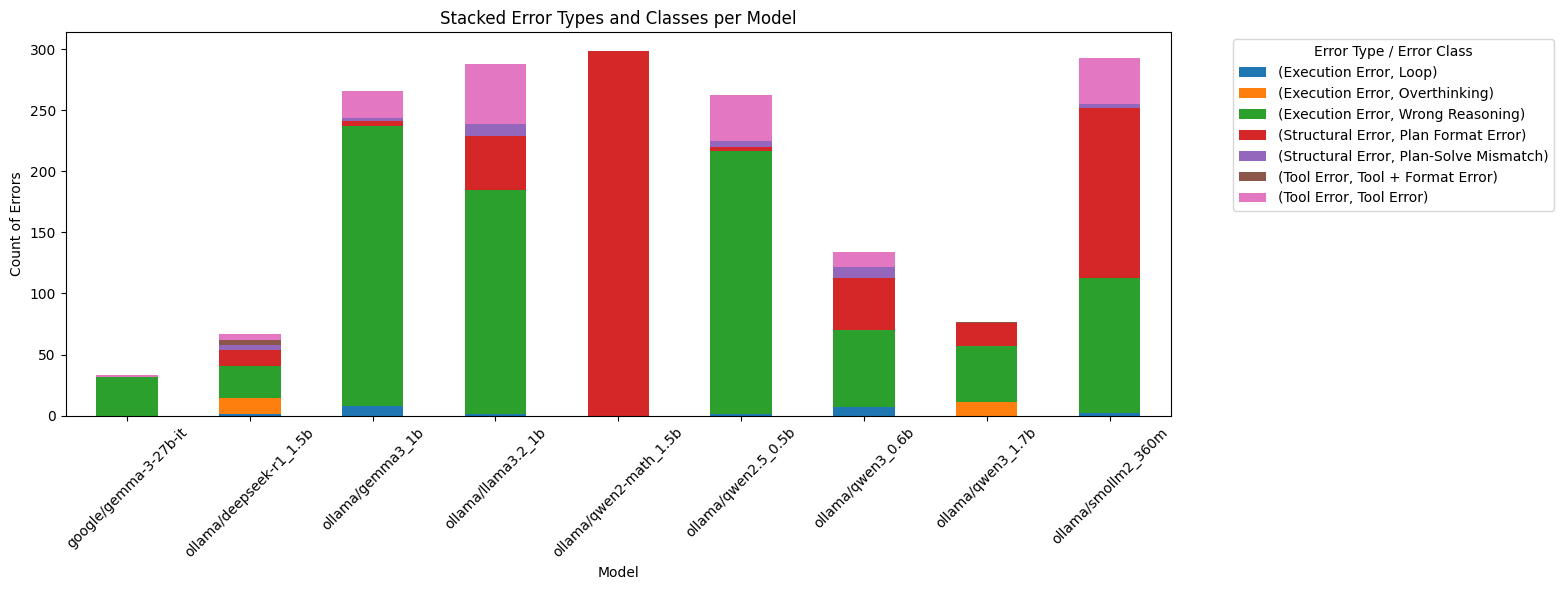

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

# Set index to "Model" to prepare for plotting
df_plot = df_err.set_index("Model")

# Plot as stacked bar chart
df_plot.plot(kind="bar", stacked=True, figsize=(12, 6))

plt.ylabel("Count of Errors")
plt.title("Stacked Error Types and Classes per Model")
plt.xticks(rotation=45)
plt.tight_layout()
plt.legend(title="Error Type / Error Class", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

## Question Type

In [8]:
# Different question types
def classify_question_type(question):
    if "how many" in question.lower():
        return "How Many"
    elif "how much" in question.lower():
        return "How Much"
    elif "what" in question.lower():
        return "What"
    elif "calculate" in question.lower():
        return "Calculate"
    elif "how" in question.lower():
        return "How"
    return np.nan

df_qt = df.copy()
df_qt['Question_Type'] = df['question'].apply(classify_question_type)
print("NAN Question Types:", df_qt['Question_Type'].isna().sum())

# show ten questions with NaN question types
for question in df_qt[df_qt['Question_Type'].isna()]['question']:
    print(question)

# Filter df by unique ids and collect number of unique question types
def get_question_type_mapping():
    seen_ids = set()
    question_type_mapping = {}
    for _, row in df_qt.iterrows():
        if row['question'] not in seen_ids:
            seen_ids.add(row['question'])
            if row['Question_Type'] not in question_type_mapping:
                question_type_mapping[row['Question_Type']] = 0
            question_type_mapping[row['Question_Type']] += 1
    return question_type_mapping

question_type_mapping = get_question_type_mapping()

question_type_df = pd.DataFrame(list(question_type_mapping.items()), columns=['Question Type', 'Count'])
question_type_df = question_type_df.sort_values(by='Count', ascending=False)
question_type_df

NAN Question Types: 0


,Question Type,Count
1,How Many,166
0,How Much,76
3,What,29
2,How,15
4,Calculate,14


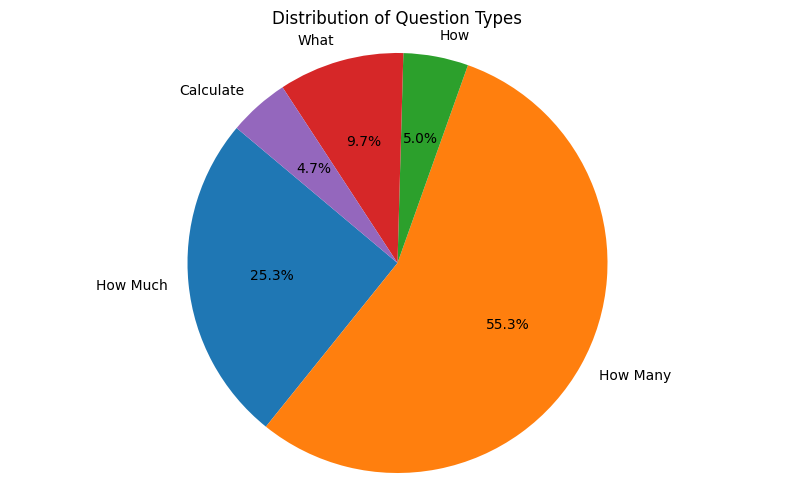

In [9]:
# Make a pie chart of the question types
import matplotlib.pyplot as plt
question_types = list(question_type_mapping.keys())
question_counts = list(question_type_mapping.values())
plt.figure(figsize=(10, 6))
plt.pie(question_counts, labels=question_types, autopct='%1.1f%%', startangle=140)
plt.title('Distribution of Question Types')
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

In [10]:
qtypes_df = df_qt.groupby(["Model", "Question_Type"]).agg({
    "is_correct": "sum"
}).reset_index()

qtypes_df["Total_Questions"] = qtypes_df["Question_Type"].map(lambda x: question_type_mapping.get(x, 0))
qtypes_df["Correct_Score"] = qtypes_df["is_correct"] / qtypes_df["Total_Questions"] * 100
qtypes_pivot = qtypes_df.pivot_table(index='Question_Type', columns='Model', values='Correct_Score', fill_value=0)
qtypes_pivot

Model,google/gemma-3-27b-it,ollama/deepseek-r1_1.5b,ollama/gemma3_1b,ollama/llama3.2_1b,ollama/qwen2-math_1.5b,ollama/qwen2.5_0.5b,ollama/qwen3_0.6b,ollama/qwen3_1.7b,ollama/smollm2_360m
Question_Type,,,,,,,,,
Calculate,92.857143,64.285714,7.142857,0.000000,0.000000,14.285714,57.142857,71.428571,0.000000
How,86.666667,66.666667,6.666667,0.000000,0.000000,6.666667,33.333333,66.666667,0.000000
How Many,90.963855,80.722892,7.831325,4.216867,0.000000,13.855422,59.638554,74.096386,1.204819
How Much,86.842105,73.684211,21.052632,6.578947,1.315789,10.526316,53.947368,78.947368,3.947368
What,82.758621,79.310345,10.344828,0.000000,0.000000,10.344828,44.827586,68.965517,6.896552


In [11]:
qtypes_dict = qtypes_pivot.to_dict()
significant_results = {}
for model, scores in qtypes_dict.items():
    items = list(scores.items())
    significant_results[model] = []
    for i in range(len(items)):
        for j in range(i + 1, len(items)):
            item1, item2 = items[i], items[j]
            p1 = item1[1]/100
            p2 = item2[1]/100
            n1 = question_type_mapping.get(item1[0], 0)
            n2 = question_type_mapping.get(item2[0], 0)
            
            if n1 == 0 or n2 == 0:
                raise ValueError(f"Question type '{item1[0]}' or '{item2[0]}' not found in mapping.")
            result = compare_accuracies_v3(p1, n1, p2, n2)
            if result.is_significant:
                significant_results[model].append((item1[0], item1[1], item2[0], item2[1], result.p_value, result.is_significant))
                print(f"Comparing {p1} (n={n1}) with {p2} (n={n2}) for model {model}")

significant_results_df = pd.DataFrame([
    {
        'Model': model,
        'Type1': item[0],
        'Score1': item[1],
        'Type2': item[2],
        'Score2': item[3],
        'p_value': item[4],
        'is_significant': item[5]
    }
    for model, items in significant_results.items()
    for item in items
])
significant_results_df.head(10)

Comparing 0.0783132530120482 (n=166) with 0.21052631578947367 (n=76) for model ollama/gemma3_1b


,Model,Type1,Score1,Type2,Score2,p_value,is_significant
0,ollama/gemma3_1b,How Many,7.831325,How Much,21.052632,0.009819,True


Interpretation

- **Gemma3 1b**: performs significantly worse on *how many* than on *how much*

# Plans

In [3]:
df_plans = get_gsm8k_df("ReWOO", include=["model_history"])

def get_plan_counter(model_history):
    try:
        history = eval(model_history)
        number_plans = len(history[0]["plan"]["steps"])
    except Exception:
        number_plans = 0
    return number_plans

df_plans['Plan_Counter'] = df_plans['model_history'].apply(get_plan_counter)
df_plans['Plan_Used'] = df_plans['Plan_Counter'] > 0

df_plans.groupby(['Model']).agg({
    'Plan_Counter': 'sum',
    'Plan_Used': 'mean',
    'is_correct': 'mean'
})

gemma-3-27b-it.xlsx
qwen3_1.7b.xlsx
smollm2_360m.xlsx
qwen2-math_1.5b.xlsx
qwen3_0.6b.xlsx
qwen2.5_0.5b.xlsx
gemma3_1b.xlsx
deepseek-r1_1.5b.xlsx
llama3.2_1b.xlsx


,Plan_Counter,Plan_Used,is_correct
Model,,,
google/gemma-3-27b-it,1143,1.000000,0.890000
ollama/deepseek-r1_1.5b,662,0.953333,0.773333
ollama/gemma3_1b,752,1.000000,0.113333
ollama/llama3.2_1b,392,0.850000,0.040000
ollama/qwen2-math_1.5b,1,0.003333,0.003333
ollama/qwen2.5_0.5b,588,0.993333,0.123333
ollama/qwen3_0.6b,855,0.903333,0.553333
ollama/qwen3_1.7b,854,0.973333,0.743333
ollama/smollm2_360m,840,0.566667,0.023333


In [5]:
# Check if tool was used if it was correct
df_plans.groupby(['Model']).agg({
    'Plan_Counter': 'mean'
})

,Plan_Counter
Model,
google/gemma-3-27b-it,3.810000
ollama/deepseek-r1_1.5b,2.206667
ollama/gemma3_1b,2.506667
ollama/llama3.2_1b,1.306667
ollama/qwen2-math_1.5b,0.003333
ollama/qwen2.5_0.5b,1.960000
ollama/qwen3_0.6b,2.850000
ollama/qwen3_1.7b,2.846667
ollama/smollm2_360m,2.800000


# Plan vs Solve

In [7]:
from math_datasets.datasets import Dataset
import re

df_plan_vs_solve = get_gsm8k_df("ReWOO", include=["model_history"])

def check_solve_reasoning(reasoning: str) -> bool:
    splits = reasoning.split("---------------------------------")
    # remove #E1 = and #E2 = from the equations with regex
    equations = re.sub(r"#E\d+ = ", "", splits[1].strip())
    equation_results = equations.split("\n")
    equation_results = [Dataset.extract_answer(eq.strip()) for eq in equation_results]
    solve = splits[-1].strip()
    float_solve = Dataset.extract_answer(solve)
    if float_solve is None:
        return False
    return float_solve in equation_results


df_plan_vs_solve["plan_vs_solve"] = df_plan_vs_solve["reasoning"].apply(check_solve_reasoning)
df_plan_vs_solve.groupby(["Model", "plan_vs_solve"]).agg({
    "is_correct": "mean",
    "question": "count"
})

gemma-3-27b-it.xlsx
qwen3_1.7b.xlsx
smollm2_360m.xlsx
qwen2-math_1.5b.xlsx
qwen3_0.6b.xlsx
qwen2.5_0.5b.xlsx
gemma3_1b.xlsx
deepseek-r1_1.5b.xlsx
llama3.2_1b.xlsx


is_correct  question
Model                   plan_vs_solve                      
google/gemma-3-27b-it   False            0.250000         4
                        True             0.898649       296
ollama/deepseek-r1_1.5b False            0.668605       172
                        True             0.914062       128
ollama/gemma3_1b        False            0.123223       211
                        True             0.089888        89
ollama/llama3.2_1b      False            0.031690       284
                        True             0.187500        16
ollama/qwen2-math_1.5b  False            0.000000       299
                        True             1.000000         1
ollama/qwen2.5_0.5b     False            0.107143       168
                        True             0.143939       132
ollama/qwen3_0.6b       False            0.438202       178
                        True             0.721311       122
ollama/qwen3_1.7b       False            0.717742       124
                        True             0.761364       176
ollama/smollm2_360m     False            0.015267       262
                        True             0.078947        38

How to read this table:

* If the solve answer is based on the plan, what is the accuracy then
    * If the accuracy is low, this suggests wrong reasoning in the plan
* If the solve answer is not based on the plan
    * and the accuracy is high, this means the solve rethinks the wrong plan and provides the correct answer
    * it says nothing about the correctness of the plan (connect with AutoSolve: AutoSolve underperforms)

# Auto Solve

In [9]:
from math_datasets.generators.rewoo_v1 import PlanExecutor
from math_datasets.datasets import Dataset

df_auto_solve = get_gsm8k_df("ReWOO", include=["model_history"])
plan_executor = PlanExecutor()

def execute_plan(model_history):
    try:
        # parse the model history as list of dictionaries
        if isinstance(model_history, str):
            model_history = eval(model_history)

        plan_str = model_history[0]["plan"]["plan_string"]
        return plan_executor.follow_plan(plan_str)[-1]["solve"]["result"]
    except Exception as e:
        return None

df_auto_solve["AutoSolve"] = df_auto_solve["model_history"].apply(execute_plan)

def extract_answer(answer):
    if answer is None:
        return None
    return Dataset.extract_answer(answer)

df_auto_solve["target_answer_float"] = df_auto_solve["target_answer"].apply(extract_answer)
df_auto_solve["AutoSolve_float"] = df_auto_solve["AutoSolve"].apply(extract_answer)

df_auto_solve["AutoSolve_correct"] = df_auto_solve["AutoSolve_float"] == df_auto_solve["target_answer_float"]
df_auto_solve["AutoSolve_correct"].value_counts(), df_auto_solve["is_correct"].value_counts()
df_auto_solve.groupby(["Model"]).agg({
    "AutoSolve_correct": "mean",
    "is_correct": "mean",
    "question": "count"
})

gemma-3-27b-it.xlsx
qwen3_1.7b.xlsx
smollm2_360m.xlsx
qwen2-math_1.5b.xlsx
qwen3_0.6b.xlsx
qwen2.5_0.5b.xlsx
gemma3_1b.xlsx
deepseek-r1_1.5b.xlsx
llama3.2_1b.xlsx


,AutoSolve_correct,is_correct,question
Model,,,
google/gemma-3-27b-it,0.876667,0.890000,300
ollama/deepseek-r1_1.5b,0.380000,0.773333,300
ollama/gemma3_1b,0.043333,0.113333,300
ollama/llama3.2_1b,0.043333,0.040000,300
ollama/qwen2-math_1.5b,0.003333,0.003333,300
ollama/qwen2.5_0.5b,0.103333,0.123333,300
ollama/qwen3_0.6b,0.110000,0.553333,300
ollama/qwen3_1.7b,0.236667,0.743333,300
ollama/smollm2_360m,0.016667,0.023333,300


Quick Interpretation: For all models except for Llama and Gemma 27B, AutoSolve performs significantly worse